In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('TablaComparativaConcentrado.xlsx')
print(df.head())

  Unnamed: 0  Threshold  YOLO v8  MMPose v1.3  MediaPipe v0.10
0        PCK        0.1  94.8000      99.3200          97.2400
1        PCK        0.5  97.7000     100.0000         100.0000
2        PCK        0.9  98.6700     100.0000         100.0000
3        mAP        0.1   0.9072       0.9973           0.8662
4        mAP        0.5   0.8770       0.9923           0.8662


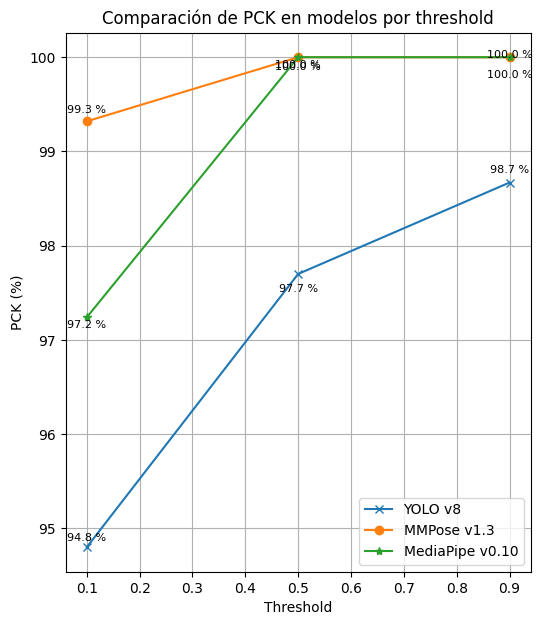

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que tu DataFrame se llama df
df_pck = df[df['Unnamed: 0'] == 'PCK']  # Filtramos solo las filas con PCK

# Configuramos el gráfico
plt.figure(figsize=(6, 7))

# Graficamos cada modelo
models = {
    'YOLO v8': {'marker': 'x', 'color': None},
    'MMPose v1.3': {'marker': 'o', 'color': None},
    'MediaPipe v0.10': {'marker': '*', 'color': None}
}

# Primero graficamos todas las líneas
for model, style in models.items():
    plt.plot(df_pck['Threshold'], df_pck[model], 
             marker=style['marker'], 
             label=model)

# Luego añadimos los textos con un pequeño desplazamiento vertical para evitar superposición
vertical_offset = 0.005  # Ajusta este valor según necesites

for model in models.keys():
    for x, y in zip(df_pck['Threshold'], df_pck[model]):
        # Aplicamos un pequeño desplazamiento aleatorio para evitar superposición
        y_offset = y + (np.random.rand() - 0.5) * vertical_offset * max(df_pck[model])
        plt.text(x, y_offset, f'{y:.1f} %', 
                 fontsize=8, 
                 ha='center', 
                 va='bottom')

# Añadimos títulos y etiquetas
plt.title('Comparación de PCK en modelos por threshold')
plt.xlabel('Threshold')
plt.ylabel('PCK (%)')
plt.legend()
plt.grid(True)

# Mostramos el gráfico
plt.show()

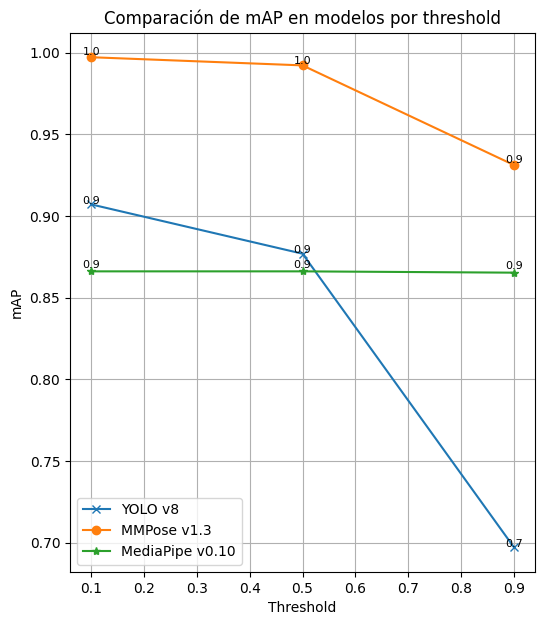

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con mAP
df_mAP = df[df['Unnamed: 0'] == 'mAP']

# Configuramos el gráfico
plt.figure(figsize=(6, 7))

# Graficamos cada modelo
models = {
    'YOLO v8': {'marker': 'x', 'color': None},
    'MMPose v1.3': {'marker': 'o', 'color': None},
    'MediaPipe v0.10': {'marker': '*', 'color': None}
}

# Primero graficamos todas las líneas
for model, style in models.items():
    plt.plot(df_mAP['Threshold'], df_mAP[model], 
             marker=style['marker'], 
             label=model)

# Añadimos los valores con desplazamiento vertical
vertical_offset = 0.001  # Ajusta este valor según el rango de tus datos

for model in models.keys():
    for x, y in zip(df_mAP['Threshold'], df_mAP[model]):
        # Aplicamos desplazamiento alternado para mejor legibilidad
        offset = vertical_offset * (list(models.keys()).index(model) - 1)
        plt.text(x, y + offset, f'{y:.1f}', 
                 fontsize=8, 
                 ha='center', 
                 va='bottom')

# Añadimos títulos y etiquetas
plt.title('Comparación de mAP en modelos por threshold')
plt.xlabel('Threshold')
plt.ylabel('mAP')
plt.legend()
plt.grid(True)

plt.show()

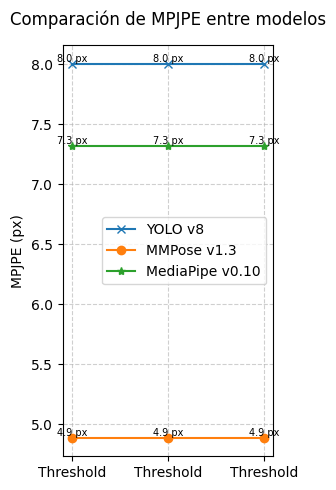

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtramos solo las filas con MPJPE
df_mpjpe = df[df['Unnamed: 0'] == 'MPJPE']

# Configuramos el gráfico
plt.figure(figsize=(3.15, 5))

# Como no hay Threshold, usamos posiciones fijas en el eje x
x_positions = range(len(df_mpjpe))  # Posiciones 0, 1, 2,...

# Graficamos cada modelo
plt.plot(x_positions, df_mpjpe['YOLO v8'], marker='x', label='YOLO v8')
plt.plot(x_positions, df_mpjpe['MMPose v1.3'], marker='o', label='MMPose v1.3')
plt.plot(x_positions, df_mpjpe['MediaPipe v0.10'], marker='*', label='MediaPipe v0.10')

# Añadimos los valores en cada punto
for i in x_positions:
    plt.text(i, df_mpjpe['YOLO v8'].iloc[i], f"{df_mpjpe['YOLO v8'].iloc[i]:.1f} px", 
             ha='center', va='bottom', fontsize=7)
    plt.text(i, df_mpjpe['MMPose v1.3'].iloc[i], f"{df_mpjpe['MMPose v1.3'].iloc[i]:.1f} px",
             ha='center', va='bottom', fontsize=7)
    plt.text(i, df_mpjpe['MediaPipe v0.10'].iloc[i], f"{df_mpjpe['MediaPipe v0.10'].iloc[i]:.1f} px",
             ha='center', va='bottom', fontsize=7)

# Configuración de ejes y título
plt.title('Comparación de MPJPE entre modelos', pad=15)
plt.xticks(x_positions, [f"Threshold" for i in x_positions])  # Etiquetas genéricas
plt.ylabel('MPJPE (px)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Mejor ajuste
plt.tight_layout()
plt.show()

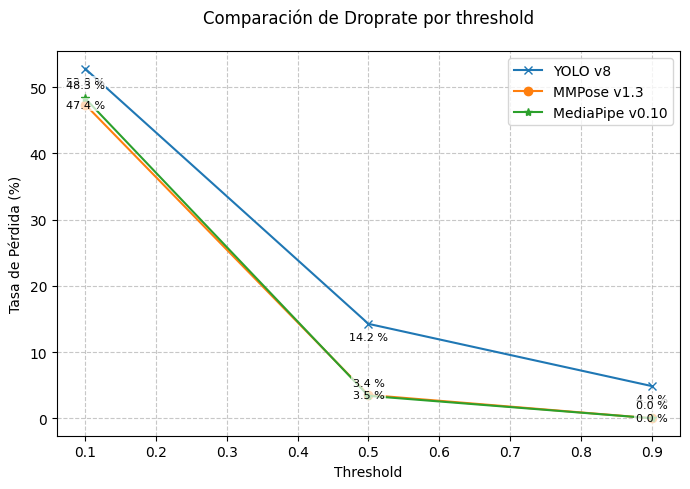

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con Droprate
df_droprate = df[df['Unnamed: 0'] == 'Droprate']

# Configuramos el gráfico
plt.figure(figsize=(7, 5))

# Definimos modelos y estilos
models = {
    'YOLO v8': {'marker': 'x', 'color': None},
    'MMPose v1.3': {'marker': 'o', 'color': None},
    'MediaPipe v0.10': {'marker': '*', 'color': None}
}

# Graficamos cada modelo
for model, style in models.items():
    plt.plot(df_droprate['Threshold'], df_droprate[model], 
             marker=style['marker'], 
             label=model,
             linestyle='-')

# SOLUCIÓN 1: Desplazamiento escalonado (simple)
vertical_offset = 2.0  # Ajusta según el rango de tus datos

for i, model in enumerate(models.keys()):
    for x, y in zip(df_droprate['Threshold'], df_droprate[model]):
        # Desplazamiento alternado basado en el índice del modelo
        offset = vertical_offset * (i - 1)
        plt.text(x, y + offset, f'{y:.1f} %',  # Mostrar porcentaje
                 fontsize=8, 
                 ha='center', 
                 va='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Añadimos títulos y etiquetas mejoradas
plt.title('Comparación de Droprate por threshold', pad=20)
plt.xlabel('Threshold')
plt.ylabel('Tasa de Pérdida (%)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajuste fino del layout
plt.tight_layout()

# Mostramos el gráfico
plt.show()

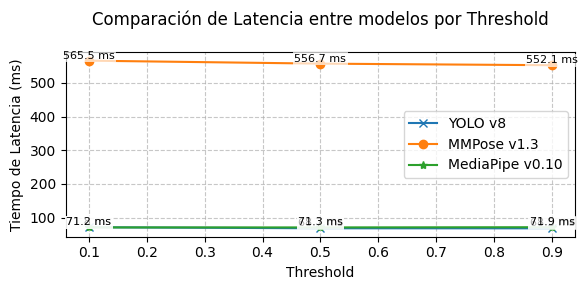

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con Latencia
df_latencia = df[df['Unnamed: 0'] == 'Latencia']

# Configuramos el gráfico
# plt.figure(figsize=(6, 7))
plt.figure(figsize=(6, 3))

# Definimos modelos y estilos
models = {
    'YOLO v8': {'marker': 'x', 'color': None},
    'MMPose v1.3': {'marker': 'o', 'color': None},
    'MediaPipe v0.10': {'marker': '*', 'color': None}
}

# Graficamos cada modelo
for model, style in models.items():
    plt.plot(df_latencia['Threshold'], df_latencia[model], 
             marker=style['marker'], 
             label=model,
             linestyle='-')

# Añadimos los valores con desplazamiento escalonado
vertical_offset = 0.1  # Ajusta este valor según el rango de tus datos de latencia

for i, model in enumerate(models.keys()):
    for x, y in zip(df_latencia['Threshold'], df_latencia[model]):
        # Desplazamiento alternado basado en el índice del modelo
        offset = vertical_offset * (i - 1)
        plt.text(x, y + offset, f'{y:.1f} ms',  # Mostrar valor con unidades
                 fontsize=8, 
                 ha='center', 
                 va='bottom',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Añadimos títulos y etiquetas mejoradas
plt.title('Comparación de Latencia entre modelos por Threshold', pad=20)
plt.xlabel('Threshold')
plt.ylabel('Tiempo de Latencia (ms)')  # Especificamos unidades
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajuste fino del layout
plt.tight_layout()

# Mostramos el gráfico
plt.show()

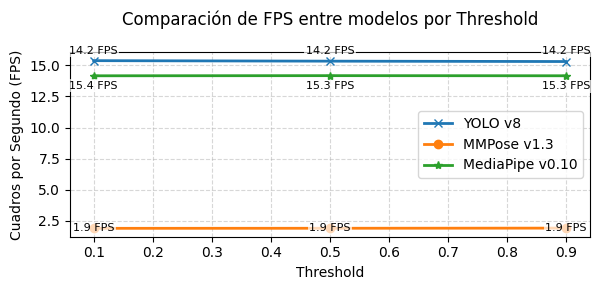

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con FPS
df_fps = df[df['Unnamed: 0'] == 'FPS']

# Configuramos el gráfico
# plt.figure(figsize=(7, 5))  # Tamaño más ancho para mejor visualización
plt.figure(figsize=(6, 3))  # Tamaño más ancho para mejor visualización

# Definimos modelos y estilos
models = {
    'YOLO v8': {'marker': 'x', 'color': None},
    'MMPose v1.3': {'marker': 'o', 'color': None},
    'MediaPipe v0.10': {'marker': '*', 'color': None}
}

# Graficamos cada modelo
for model, style in models.items():
    plt.plot(df_fps['Threshold'], df_fps[model], 
             marker=style['marker'], 
             label=model,
             linestyle='-',
             linewidth=2)

# Añadimos los valores con desplazamiento escalonado
vertical_offset = 2.0  # Ajusta según el rango de tus datos FPS

for i, model in enumerate(models.keys()):
    for x, y in zip(df_fps['Threshold'], df_fps[model]):
        # Desplazamiento alternado basado en el índice del modelo
        offset = vertical_offset * (i - 1)
        plt.text(x, y + offset, f'{y:.1f} FPS',  # Mostrar valor con unidades
                 fontsize=8, 
                 ha='center', 
                 va='center',
                 bbox=dict(facecolor='white', alpha=0.7, 
                          edgecolor='none', pad=1))

# Añadimos títulos y etiquetas mejoradas
plt.title('Comparación de FPS entre modelos por Threshold', pad=20)
plt.xlabel('Threshold')
plt.ylabel('Cuadros por Segundo (FPS)')  # Nombre completo y unidades
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)  # Grid más sutil

# Ajuste fino del layout
plt.tight_layout()

# Mostramos el gráfico
plt.show()

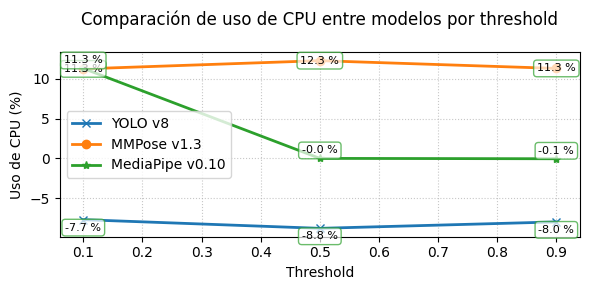

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con CPU
df_cpu = df[df['Unnamed: 0'] == 'CPU']

# Configuramos el gráfico con tamaño más ancho
# plt.figure(figsize=(6, 5))
plt.figure(figsize=(6, 3))  # Tamaño más ancho para mejor visualización

# Definimos modelos y estilos
models = {
    'YOLO v8': {'marker': 'x', 'color': '#1f77b4'},
    'MMPose v1.3': {'marker': 'o', 'color': '#ff7f0e'}, 
    'MediaPipe v0.10': {'marker': '*', 'color': '#2ca02c'}
}

# Graficamos cada modelo con estilos personalizados
for model, style in models.items():
    plt.plot(df_cpu['Threshold'], df_cpu[model],
             marker=style['marker'],
             color=style['color'],
             linestyle='-',
             linewidth=2,
             label=model)

# Añadimos los valores con desplazamiento escalonado
vertical_offset = 1.0  # Ajusta según el rango de % de CPU

for i, model in enumerate(models.keys()):
    for x, y in zip(df_cpu['Threshold'], df_cpu[model]):
        # Desplazamiento alternado para evitar superposición
        offset = vertical_offset * (i - 1)
        plt.text(x, y + offset, f'{y:.1f} %',
                 fontsize=8,
                 ha='center',
                 va='center',
                 bbox=dict(facecolor='white', 
                          edgecolor=style['color'],
                          alpha=0.7,
                          boxstyle='round,pad=0.3'))

# Configuración de ejes y título
plt.title('Comparación de uso de CPU entre modelos por threshold', 
          fontsize=12, pad=20)
plt.xlabel('Threshold', fontsize=10)
plt.ylabel('Uso de CPU (%)', fontsize=10)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

# Ajuste final para evitar cortes
plt.tight_layout()

# Mostramos el gráfico
plt.show()

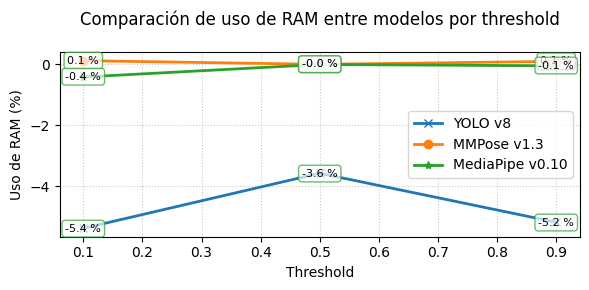

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filtramos solo las filas con RAM
df_ram = df[df['Unnamed: 0'] == 'RAM']

# Configuramos el gráfico con el mismo tamaño
# plt.figure(figsize=(6, 5))
plt.figure(figsize=(6, 3))  # Tamaño más ancho para mejor visualización


# Definimos modelos y estilos (misma estructura que CPU)
models = {
    'YOLO v8': {'marker': 'x', 'color': '#1f77b4'},
    'MMPose v1.3': {'marker': 'o', 'color': '#ff7f0e'}, 
    'MediaPipe v0.10': {'marker': '*', 'color': '#2ca02c'}
}

# Graficamos cada modelo (mismo estilo que CPU)
for model, style in models.items():
    plt.plot(df_ram['Threshold'], df_ram[model],
             marker=style['marker'],
             color=style['color'],
             linestyle='-',
             linewidth=2,
             label=model)

# Añadimos los valores con el mismo formato
vertical_offset = 0.01  # Offset ligeramente mayor para RAM (ajustable)

for i, model in enumerate(models.keys()):
    for x, y in zip(df_ram['Threshold'], df_ram[model]):
        # Mismo esquema de desplazamiento
        offset = vertical_offset * (i - 1)
        plt.text(x, y + offset, f'{y:.1f} %',
                 fontsize=8,
                 ha='center',
                 va='center',
                 bbox=dict(facecolor='white', 
                          edgecolor=style['color'],
                          alpha=0.7,
                          boxstyle='round,pad=0.3'))

# Configuración de ejes con misma estructura
plt.title('Comparación de uso de RAM entre modelos por threshold', 
          fontsize=12, pad=20)
plt.xlabel('Threshold', fontsize=10)
plt.ylabel('Uso de RAM (%)', fontsize=10)
plt.legend(loc='best')  # Misma posición de leyenda
plt.grid(True, linestyle=':', alpha=0.7)  # Mismo estilo de grid

# Ajuste final idéntico
plt.tight_layout()

# Mostramos el gráfico
plt.show()

# Generando Radar

In [13]:
import pandas as pd

df_radar = pd.read_excel('TablaComparativaRadar.xlsx')
print(df_radar.head())

  Feature  Threshold  YOLO v8  MMPose v1.3  MediaPipe v0.10
0     PCK        0.1      1.0          3.0              2.0
1     PCK        0.5      2.0          3.0              3.0
2     PCK        0.9      3.0          3.0              3.0
3     mAP        0.1      2.0          3.0              1.0
4     mAP        0.5      2.0          3.0              1.0


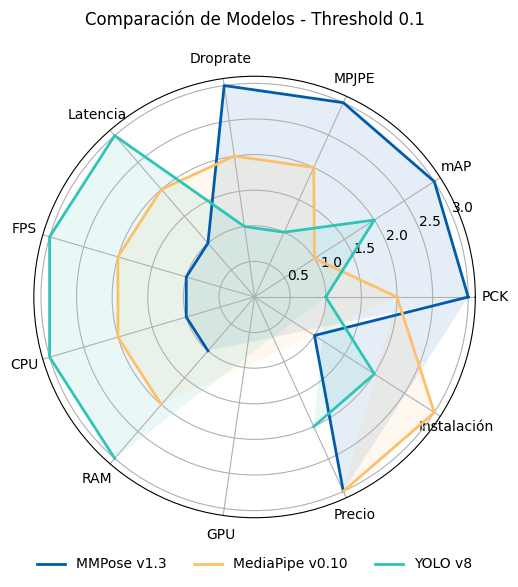

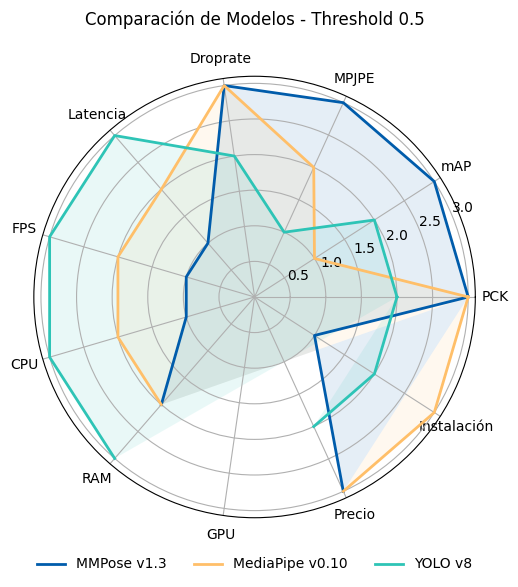

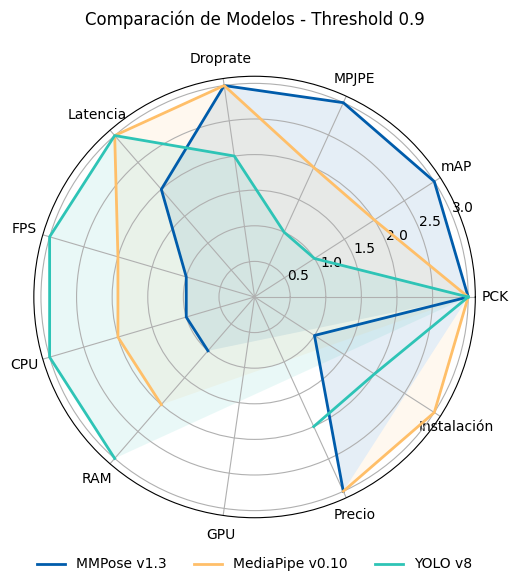

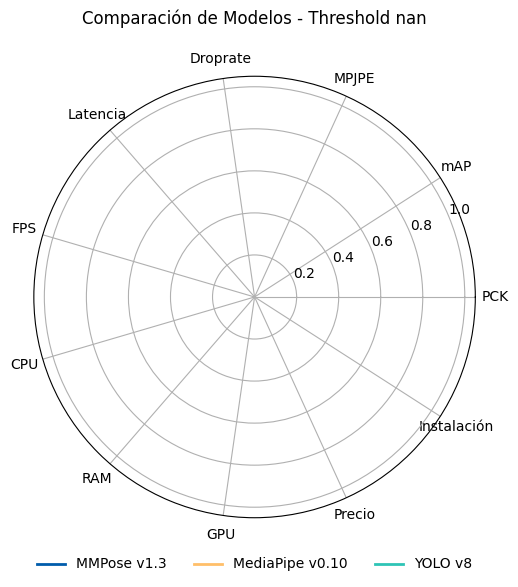

In [14]:
df_radar = df_radar.drop_duplicates(subset=['Feature', 'Threshold'])

# 2. Configuración de colores
COLORES = {
    'MMPose v1.3': '#005CAB',
    'MediaPipe v0.10': '#FFBF69',
    'YOLO v8': '#2EC4B6'
}

# 3. Función para graficar radar
def plot_radar(threshold, df):
    df_threshold = df[df['Threshold'] == threshold]
    features = df['Feature'].unique()
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'polar': True})
    
    for model in ['MMPose v1.3', 'MediaPipe v0.10', 'YOLO v8']:
        values = df_threshold.set_index('Feature')[model].reindex(features).tolist()
        values += values[:1]
        ax.plot(angles, values, color=COLORES[model], label=model, linewidth=2)
        ax.fill(angles, values, color=COLORES[model], alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.set_title(f'Comparación de Modelos - Threshold {threshold}', pad=20)
    
    # --- Ajuste clave: Leyenda en centro inferior ---
    ax.legend(
        loc='lower center',          # Posición central inferior
        bbox_to_anchor=(0.5, -0.15), # Ajuste fino de ubicación (x, y)
        ncol=3,                      # 3 columnas para mejor distribución
        frameon=False,               # Sin marco alrededor
        fontsize=10
    )
    
    plt.tight_layout()
    plt.show()

# 4. Generar gráficos
for threshold in df_radar['Threshold'].unique():
    plot_radar(threshold, df_radar)

# Graficos para la tesis

In [15]:
df = df.rename(columns={'Unnamed: 0': 'métrica'})

In [17]:
# Definir los valores deseados en la columna "métrica"
# valores_deseados = ["PCK", "mAP", "MPJPE"]
# valores_deseados = ["PCK", "mAP", "MPJPE", "Droprate", "Latencia", "FPS", "CPU", "RAM"]
valores_deseados = ["CPU", "GPU", "RAM"]

# Filtrar el DataFrame
df_filtrado = df[df["métrica"].isin(valores_deseados)]
print(df_filtrado)

   métrica  Threshold  YOLO v8  MMPose v1.3  MediaPipe v0.10
18     CPU        0.1  -7.7194      11.2620          11.3185
19     CPU        0.5  -8.8101      12.2955          -0.0057
20     CPU        0.9  -8.0014      11.3185          -0.0516
21     RAM        0.1  -5.3900       0.1193          -0.4183
22     RAM        0.5  -3.5800      -0.0013          -0.0058
23     RAM        0.9  -5.1900       0.0961          -0.0509
24     GPU        0.1   0.0000       0.0000           0.0000
25     GPU        0.5   0.0000       0.0000           0.0000
26     GPU        0.9   0.0000       0.0000           0.0000


In [18]:
# Columnas a ignorar (no son modelos)
columnas_fijas = ["métrica", "Threshold"]

# Extraer automáticamente los nombres de los modelos (todas las columnas excepto métrica y Threshold)
modelos = [col for col in df_filtrado.columns if col not in columnas_fijas]

# Función para asignar rankings (1 = mejor, 3 = peor)
# Función mejorada para asignar rankings
def rank_models(row):
    valores = row[modelos]
    metric_name = row["métrica"]
    
    # Caso especial: si todos los valores son 0, mantener 0s
    if all(v == 0 for v in valores):
        return pd.Series({modelo: 0 for modelo in modelos})
    
    # Determinar criterio de ordenamiento
    lower_is_better = ["Latencia", "MPJPE", "Droprate", "RAM", "CPU", "GPU"]
    reverse_sort = metric_name not in lower_is_better
    
    # Ordenar modelos con manejo de empates
    ranked = sorted(zip(modelos, valores), 
              key=lambda x: x[1], 
              reverse=reverse_sort)
    
    # Asignar rankings considerando empates
    ranking = {}
    current_rank = 1
    for i, (modelo, valor) in enumerate(ranked):
        if i > 0 and valor != ranked[i-1][1]:
            current_rank = i + 1
        ranking[modelo] = current_rank
    
    return pd.Series(ranking)

In [19]:
# Aplicar la función y crear df_ordered
df_ordered = df_filtrado.apply(rank_models, axis=1)
df_ordered.insert(0, "métrica", df_filtrado["métrica"])  # Añadir columna métrica
df_ordered.insert(1, "Threshold", df_filtrado["Threshold"])  # Añadir Threshold

print(df_ordered)

   métrica  Threshold  MMPose v1.3  MediaPipe v0.10  YOLO v8
18     CPU        0.1            2                3        1
19     CPU        0.5            3                2        1
20     CPU        0.9            3                2        1
21     RAM        0.1            3                2        1
22     RAM        0.5            3                2        1
23     RAM        0.9            3                2        1
24     GPU        0.1            0                0        0
25     GPU        0.5            0                0        0
26     GPU        0.9            0                0        0


# Grafico de radar

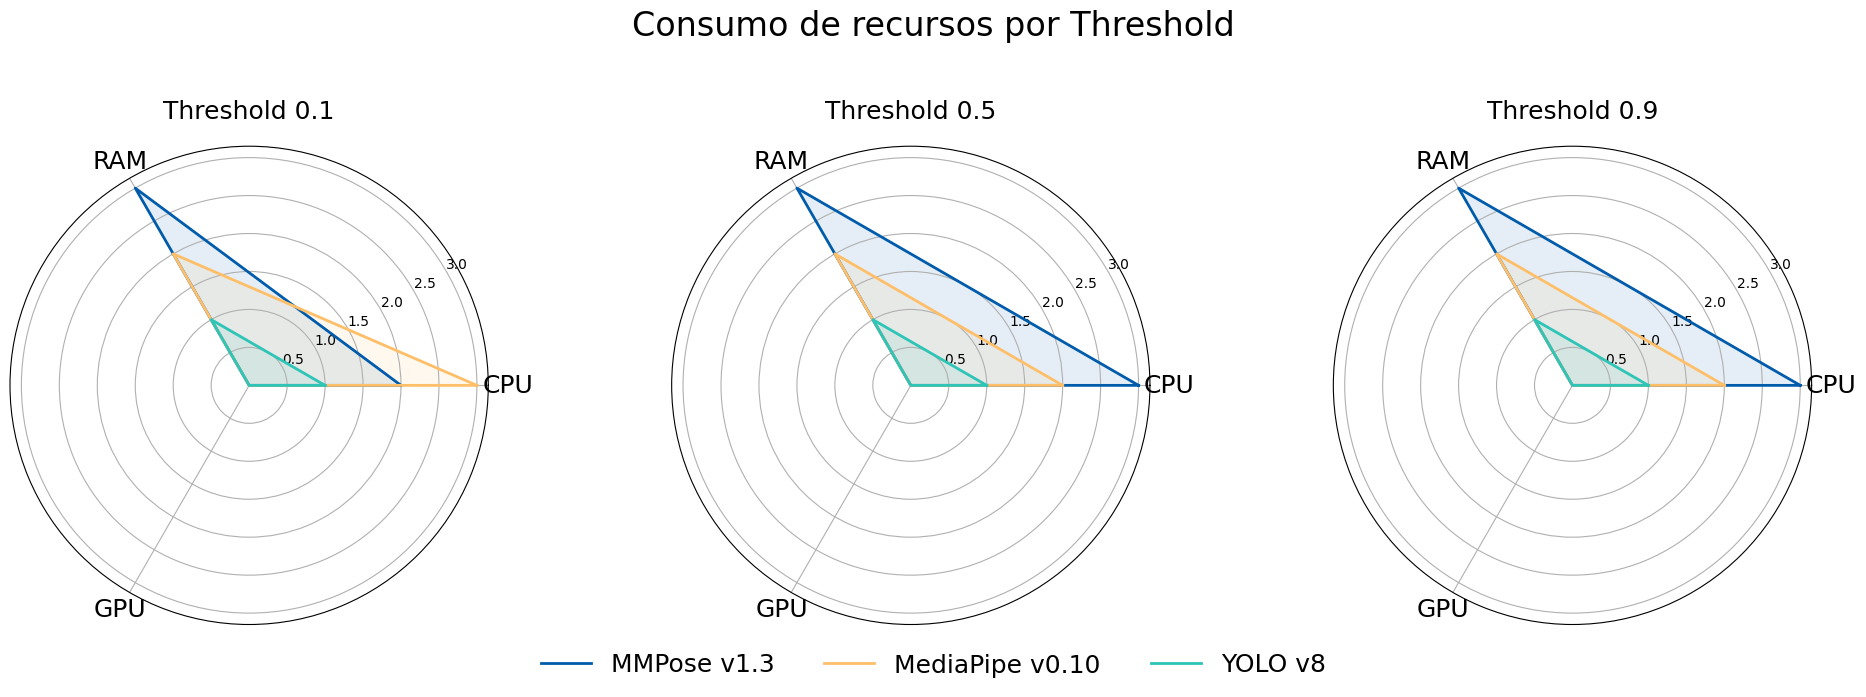

In [20]:
# Configuración de colores
COLORES = {
    'MMPose v1.3': '#005CAB',
    'MediaPipe v0.10': '#FFBF69',
    'YOLO v8': '#2EC4B6'
}

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'polar': True})
fig.suptitle('Consumo de recursos por Threshold', fontsize=24, y=1.05)

# Obtener métricas únicas y ángulos
features = df_ordered['métrica'].unique()
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

# Generar cada subplot
for ax, threshold in zip(axes, df_ordered['Threshold'].unique()):
    df_threshold = df_ordered[df_ordered['Threshold'] == threshold]
    
    for model in ['MMPose v1.3', 'MediaPipe v0.10', 'YOLO v8']:
        values = df_threshold.set_index('métrica')[model].reindex(features).tolist()
        values += values[:1]
        ax.plot(angles, values, color=COLORES[model], label=model, linewidth=2)
        ax.fill(angles, values, color=COLORES[model], alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=18)
    ax.set_title(f'Threshold {threshold}', fontsize=18, pad=20)
    ax.set_rlabel_position(30)

# Añadir leyenda única centrada
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.1),
           ncol=3,
           fontsize=18,
           frameon=False)

plt.tight_layout()
plt.show()